In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/freelancer/railway

/content/drive/MyDrive/freelancer/railway


# Steps for doing any image classification project

1- Download the dataset and upload it to google driver

2- Specify the location using %cd

3- Import all the required libraries

4- Load the dataset

5- Do the basic exploration like no of images in the folder, plot few images, plot pixel density distributionn of the image

5.1- data preprocessing (clahe, bilateral filter,edge detection)

6- Perform Data Augmentation if we have less than no of images in training (Image data generator fn)

Optional step- If data is imbalanced make it balance (undersampling, oversampling, class_weight_calculation)

6.1- we have defined the focal loss (to focus on difficult images rather than simple ones)

7- Define your CNN model or transfer learning model

8- Compile the model using Adam optimizer, loss (categorical, binary, sparse), focal loss

9- Fit the model with training and validation data and run for n number of epochs and specify the batch size

10- Once training done Save the weights and create training and loss plot

11- Evaluate the trained model on the test data using metrics like accuracy, precision, recall, f1 score.

Note-- f1 score is used when the dataset is imbalanced





12- Copy paste all the code into chatgpt to create an end to end application using streamlit framework (web application), fastapi (write your api)

13- create a file names app.py and paste all the code.

Note in the same folder store your h5 weights files also

14- Before that create virtual environment and install all the necessary libraries using uv

* pip install uv
* uv venv
* .venv\Scripts\activate
* Create a file called as requirements.txt file and mention all the libraries.
* uv pip install -r requirements.txt
* python -m streamlit run app.py

# Importing all the required libraries

In [ ]:
import numpy as np # numerical calculations
import matplotlib.pyplot as plt # data visualization
import glob # iterate through folder
import cv2 # it is used for image preprocessing
import os # creting folder and specifying api skeys securely
import seaborn as sns # statistical data visualization
import pandas as pd # loading the csv dataset
# scikit-image
from skimage.io import imshow, imread # reading and display iamges
from sklearn.model_selection import train_test_split #70:30, 80:20,, 70:20:10
from sklearn.metrics import classification_report, confusion_matrix #
# recall is much more critical

'''
tensorflow- industry grade application
pytorch- research purpose and industry grade

'''

# tensorflow is a framework used for implementing deep learning algorithm
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization, Activation, Flatten, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau




from keras import applications, callbacks, models, layers
from keras.layers import Conv2D, MaxPooling2D # (reduce the no of paramters and computation happening in the network)
from tensorflow.keras.preprocessing.image import ImageDataGenerator # interview questions

from tensorflow.keras.optimizers import Adam # for backpropogation
from keras.models import Sequential, Model, load_model #load_model("abc.h5")
import keras
import random
import shutil # to copy and move the files within folder

import warnings
warnings.filterwarnings('ignore')

In [ ]:
railway_dataset='dataset/'

train_path = os.path.join(railway_dataset, 'train')
val_path = os.path.join(railway_dataset, 'valid')

class_names = os.listdir(train_path)
class_names

['Non defective', 'Defective']

In [ ]:
class_names = os.listdir(train_path)

for class_name in class_names:
    class_dir = os.path.join(train_path, class_name)
    num_images = len(os.listdir(class_dir))
    print(f"Class: {class_name}, Number of Images: {num_images}")

Class: Non defective, Number of Images: 150
Class: Defective, Number of Images: 150


* undersampling
* oversampling
* weighting (minority will given more importance, majority will given less importance)

In [ ]:
class_names = os.listdir(val_path)

for class_name in class_names:
    class_dir = os.path.join(val_path, class_name)
    num_images = len(os.listdir(class_dir))
    print(f"Class: {class_name}, Number of Images: {num_images}")

Class: Non defective, Number of Images: 31
Class: Defective, Number of Images: 31


# Plotting few of images of the defective railway tracks

In [ ]:
def display_random_images(img_folder, num_images=3):
    plt.figure(figsize=(20, 20)) # height, width
    image_files = glob.glob(os.path.join(img_folder, '*'))
    selected_files = random.sample(image_files, num_images)

    for i, file in enumerate(selected_files):
        img = plt.imread(file) # it is reading one of the image
        ax = plt.subplot(1, num_images, i+1) # showing it to you in subplot manner
        ax.title.set_text(os.path.basename(file)) # showing the title of each images
        plt.imshow(img)

    plt.show()

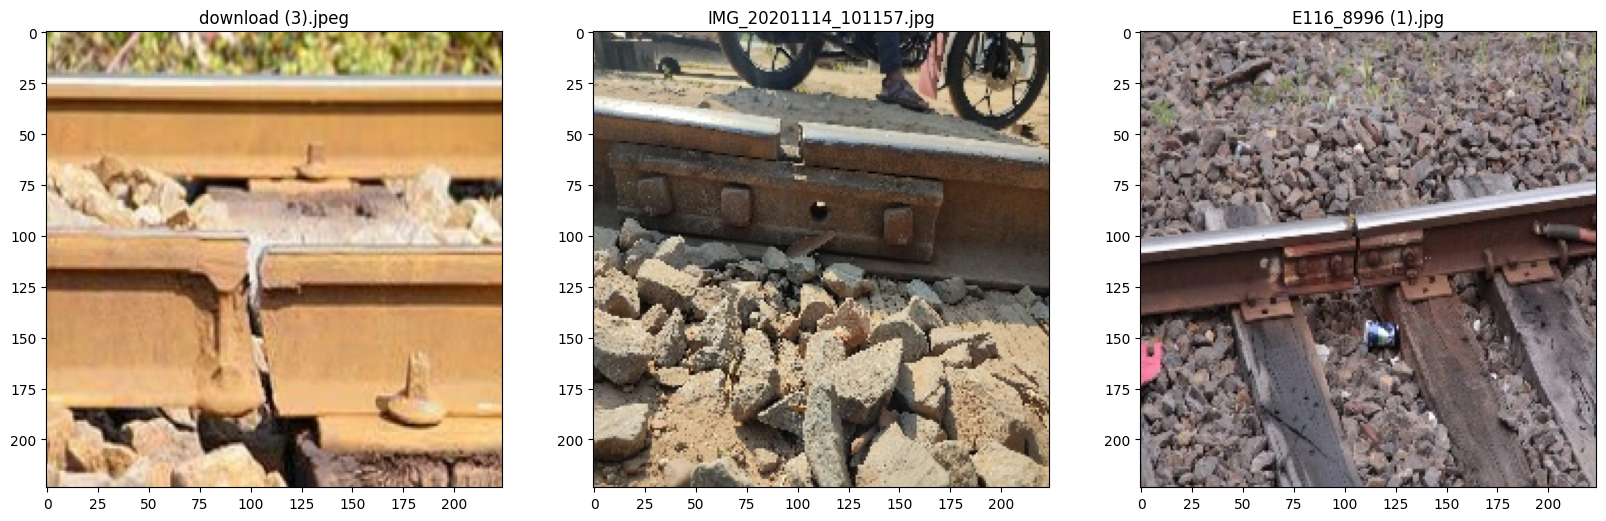

In [ ]:
img_folder = 'dataset/train/Defective'
display_random_images(img_folder)

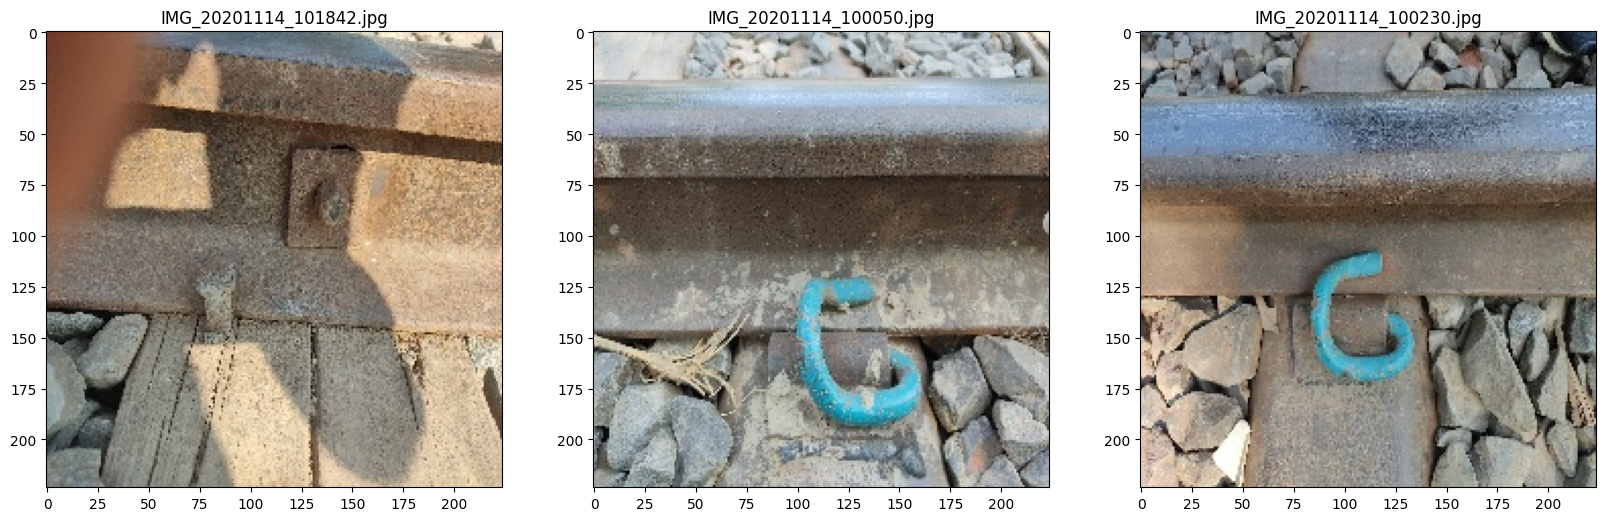

In [ ]:
img_folder='dataset/train/Non defective'
display_random_images(img_folder)

# Pixel values distribution an image

In [ ]:
def plot_image_histogram(image_path):
    # Read the image
    raw_image = plt.imread(image_path)

    # Plot the histogram
    plt.hist(raw_image.ravel(), bins=256, range=(0, 256), color='b', alpha=0.7)
    plt.axvline(x=np.mean(raw_image), color='r', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(raw_image):.4f}')
    plt.axvline(x=np.mean(raw_image) + np.std(raw_image), color='g', linestyle='dashed', linewidth=2, label=f'Stdev: {np.std(raw_image):.4f}')
    plt.axvline(x=np.mean(raw_image) - np.std(raw_image), color='g', linestyle='dashed', linewidth=2)
    plt.legend(loc='upper right')
    plt.title('Distribution of Pixel Intensities in the Image')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('# Pixels in Image')
    plt.show()

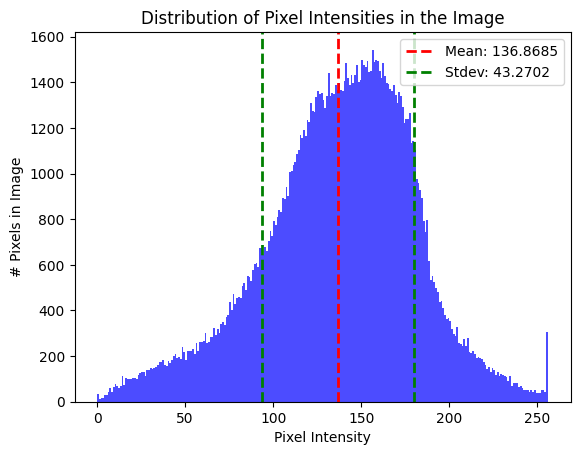

In [ ]:
plot_image_histogram('dataset/train/Non defective/IMG_20201114_100215.jpg')

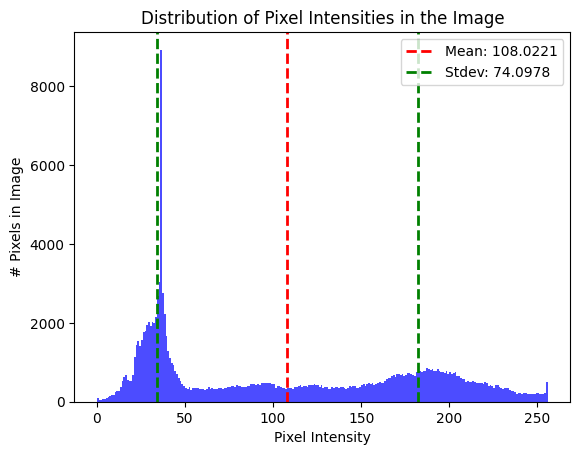

In [ ]:
plot_image_histogram('dataset/train/Defective/6411009.jpg')

# Image data Augmentation


## 1. Convert Image to 8-bit

- Converts the image into the standard **8-bit format**.
- Pixel values are represented between **0 and 255**.
- Makes the image compatible with OpenCV operations.

---

## 2. Convert RGB → LAB Color Space

- Converts the image from **RGB** to **LAB** color space.
- LAB separates:
  - **L** → Brightness
  - **A** → Green ↔ Red information
  - **B** → Blue ↔ Yellow information
- This allows us to improve brightness/contrast without heavily changing the colors.

---

## 3. CLAHE – Contrast Enhancement

- **CLAHE** stands for **Contrast Limited Adaptive Histogram Equalization**.
- Improves the contrast of the image.
- Makes dark and bright regions easier to distinguish.
- Helps reveal subtle details such as:
  - Cracks
  - Scratches
  - Surface irregularities
  - Small defects

---

## 4. Bilateral Filtering – Noise Removal

- Removes unwanted **image noise**.
- Smooths the image while preserving important edges.
- Helps maintain the boundaries of potential rail defects.

---

## 5. Sharpening – Detail Enhancement

- Makes edges and fine details more prominent.
- Enhances features such as:
  - Cracks
  - Scratches
  - Rail boundaries
  - Surface patterns
- Helps the deep learning model identify important visual features.

---

## 6. Convert RGB → Grayscale

- Converts the image from **3 color channels (RGB)** into **1 grayscale channel**.
- Grayscale represents the brightness/intensity of each pixel.
- This is required for Canny edge detection.

---

## 7. Canny Edge Detection

- Detects strong **edges and boundaries** in the image.
- Can help identify:
  - Cracks
  - Rail boundaries
  - Surface discontinuities
  - Structural irregularities
- Uses intensity changes to locate edges.

> **Note:** In the current code, Canny edges are calculated but are **not returned to the model** because the function returns only `img`.

---

## 8. Normalize Pixel Values

- Converts pixel values from:

```text
0–255

In [ ]:
IMG_SIZE = 224

# ===================== CUSTOM PREPROCESS FUNCTION =====================
def preprocess_image(img):
    img = img.astype(np.uint8)

    # 1. CLAHE (normalization)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # 2. Bilateral Filter
    img = cv2.bilateralFilter(img, 9, 75, 75)

    # 3. Sharpen
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)

    # 4. Edge Detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edges = np.expand_dims(edges, axis=-1)

    # 5. Normalize RGB
    img = img / 255.0
    edges = edges / 255.0


    return img

# ===================== DATA GENERATORS =====================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=15,
    zoom_range=0.2,
    brightness_range=[0.7,1.3],
    horizontal_flip=True
)


In [ ]:

# flow_from_directory--- read the dataset from folder
# flow_from_dataframe-- reading the image from csv file
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    color_mode='rgb',
    shuffle=True, # in the training data you have to do the shuffling
    seed=42, # freeze the result
    class_mode='categorical') # binary # sparse



val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)

val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=16,
    color_mode='rgb',
    shuffle=False, # no shuffling in validation or testing time
    class_mode='categorical')

Found 299 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


In [ ]:
# this is optional
# this code is only applied when we have the problem of data imbalance
class_counts = np.bincount(train_gen.classes) #100, 50
total_samples = np.sum(class_counts) #150
class_weights = {0: total_samples / (2.0 * class_counts[0]),
                 1: total_samples / (2.0 * class_counts[1])}

print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0033557046979866), 1: np.float64(0.9966666666666667)}


In [ ]:
SST=train_gen.n//train_gen.batch_size #299/16 # step_size_training
SSV  =val_gen.n//val_gen.batch_size # 62/16  #step_size_validation
num_epochs = 30

# Applying focal loss

“Don’t waste time on easy examples, focus on difficult ones”


* Highly Imbalanced Dataset
* Model Predicts Only One Class
* Too Many Easy Samples
* Object Detection Problems
* Precision–Recall Tradeoff Important
* Noisy or Ambiguous Data
* When Cross-Entropy Fails

In [ ]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * cross_entropy)
    return loss

# Convolutional Neural network

In [ ]:
model = Sequential() # to initialize our neural network

# Input layer # no of neuron--- multiple of 8
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3))) # 3 means rgb

# First hidden layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Second hidden layer
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Third hidden layer
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected layer
model.add(Flatten()) #2d matrix into 1d matrix
model.add(Dense(512, activation='relu')) # fully connected layer
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(2, activation='softmax'))# 1- sigmoid
print(model.summary())
# https://chatgpt.com/share/6873c051-2268-8008-b609-392fc98f3199

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 220, 220, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 220, 220, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 108, 108, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 108, 108, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    88,605,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,998,466 (339.50 MB)

 Trainable params: 88,996,546 (339.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [ ]:
# Compiling the model
model.compile(loss=focal_loss(gamma=2, alpha=0.25),  # ✅ Focal Loss applied
              optimizer="adam", # optimizer job is used to minimize the loss function
              metrics=['accuracy']) #regression--mean squared error

In [ ]:
# ======================= CALLBACKS =======================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)

In [ ]:
# ===================== TRAIN =====================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25
)


Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5418 - loss: 0.1276 - val_accuracy: 0.5323 - val_loss: 0.0362
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 581ms/step - accuracy: 0.5819 - loss: 0.0855 - val_accuracy: 0.5000 - val_loss: 0.3866
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 548ms/step - accuracy: 0.6555 - loss: 0.0670 - val_accuracy: 0.5000 - val_loss: 0.5135
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 504ms/step - accuracy: 0.6355 - loss: 0.0643 - val_accuracy: 0.5000 - val_loss: 0.4983
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step - accuracy: 0.6455 - loss: 0.0689 - val_accuracy: 0.5000 - val_loss: 0.4031
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 582ms/step - accuracy: 0.6488 - loss: 0.0692 - val_accuracy: 0.5000 - val_loss: 0.2743
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 591ms/step - accuracy: 0.6823 - loss: 0.0577 - val_accuracy: 0.5000 - val_loss: 0.2808
Epoch 8/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 539ms/step - accuracy: 0.6789 - loss: 0.0474 - val_accurac

In [ ]:
# saving the model or save your result
model.save('model_cnn.keras')

In [ ]:
def plot_metrics(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_' + metric])
    plt.title(f'Model {metric}')
    plt.ylabel(metric)
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

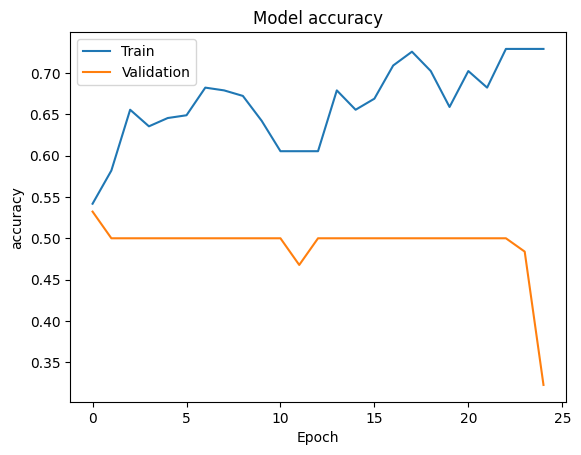

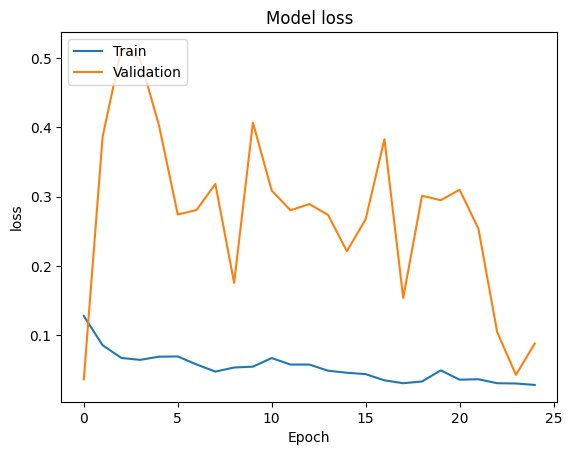

In [ ]:
# Plotting accuracy and loss
plot_metrics(history, 'accuracy')
plot_metrics(history, 'loss')

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step


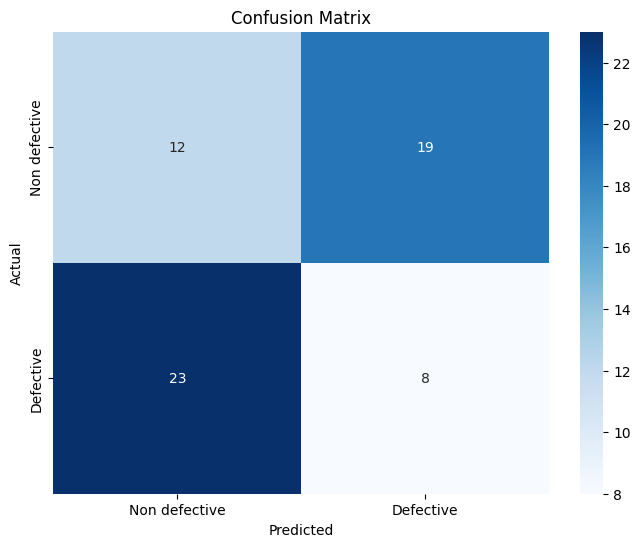

In [ ]:
# model evaluation
pred=model.predict(val_gen)
y_pred = np.argmax(pred,axis=1)
y_actual = val_gen.classes

cm = confusion_matrix(y_actual, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
labels = ['Defective', 'Non Defective']

print(classification_report(y_actual, y_pred, target_names=labels))

               precision    recall  f1-score   support

    Defective       0.34      0.39      0.36        31
Non Defective       0.30      0.26      0.28        31

     accuracy                           0.32        62
    macro avg       0.32      0.32      0.32        62
 weighted avg       0.32      0.32      0.32        62



# Project

* https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification

* It is a multiclass classification problem